# Load Forecasting Models – Comparison

| **Model Type**            | **Examples**                         | **Pros**                                                                 | **Cons**                                                                 | **Best for (Time Horizon)**      |
|----------------------------|--------------------------------------|--------------------------------------------------------------------------|--------------------------------------------------------------------------|----------------------------------|
| **Statistical – Regression** | Linear Regression, Multiple Regression | - Simple, interpretable<br>- Easy to implement<br>- Handles weather & calendar variables well | - Assumes linear relationships<br>- Limited with nonlinear demand | Short-term to Medium-term |
| **Time Series**            | ARIMA, SARIMA, Holt-Winters          | - Captures trends & seasonality<br>- Works well with historical demand    | - Struggles with sudden changes (e.g., holidays, weather extremes)<br>- Needs stationary data | Short-term (hours–days) |
| **Machine Learning**       | ANN, SVR, Random Forests, XGBoost    | - Handles nonlinear demand<br>- Uses many features (weather, events)<br>- High accuracy | - Needs lots of data<br>- Less transparent (“black box”) | Short-term to Medium-term |
| **Deep Learning**          | LSTM, CNN-LSTM                       | - Learns complex temporal patterns<br>- Good for sequential & spatial demand<br>- Strong accuracy on large datasets | - High computational cost<br>- Requires large data sets | Short-term (minutes–days) |
| **Hybrid / Ensemble**      | ARIMA + ANN, Boosted Trees, Model Averaging | - Combines strengths of multiple models<br>- Robust to varying conditions | - More complex to develop & maintain | Short-term & Medium-term |
| **Econometric / Trend Models** | GDP-based regression, Growth models | - Incorporates economic & demographic factors<br>- Good for planning capacity & investments | - Poor at short-term fluctuations<br>- Needs macroeconomic data | Long-term (months–years) |
| **Probabilistic Forecasting** | Quantile Regression, Bayesian Models | - Provides uncertainty ranges<br>- Useful for risk management & planning | - More complex<br>- Needs advanced statistical expertise | All horizons (esp. for planning) |



# A linear regression model for 24-hour-ahead load forecasting




In [ ]:
# Install required libraries in Colab
!pip install tensorflow scikit-learn

In [ ]:
# Step 1: Install the required library
# In Google Colab, run this cell first to install the entsoe-py library.
# This library makes it easy to access the ENTSO-E API without dealing with raw HTTP requests.
!pip install entsoe-py

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
from datetime import datetime, timedelta
import requests
import holidays
from entsoe import EntsoePandasClient  # For ENTSO-E API
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Data Preparation and Feature Engineering (15-Minute Data)

In [ ]:
# User Input: ENTSO-E API Key (get free from transparency@entsoe.eu)
# If you don't have it yet, set api_key = 'your_key_here' and run; it will use fallback sample.
api_key = "your-key"  # Replace with your actual key!

# Date range: Historical data up to March 22, 2025 (today in scenario)
start_date = pd.Timestamp('2023-01-01', tz='Europe/Berlin')
end_date = pd.Timestamp('2025-03-22 23:00:00', tz='Europe/Berlin')

In [ ]:
client = EntsoePandasClient(api_key=api_key)
# Query actual total load (MW) for DE (includes 50Hertz/Berlin)
load_series = client.query_load('DE_LU', start=start_date, end=end_date)

load_column = 'Actual Load' if 'Actual Load' in load_series.columns else load_series.columns[0]
load_data = pd.DataFrame({'datetime': load_series.index, 'load_mw': load_series[load_column].values})

In [ ]:
# --- 2. Feature Engineering ---
# Set datetime as the index
load_data['datetime'] = pd.to_datetime(load_data['datetime'])
load_data = load_data.set_index('datetime')
load_data = load_data.sort_index()

# Time-based features
load_data['hour_of_day'] = load_data.index.hour
load_data['day_of_week'] = load_data.index.dayofweek
load_data['month'] = load_data.index.month
load_data['quarter_of_hour'] = load_data.index.minute // 15 # New feature for 15-min data

# Lagged features (adjusted for 15-minute intervals)
# 24 hours ago = 24 * 4 = 96 steps
load_data['lag_96'] = load_data['load_mw'].shift(96)

# 1 week ago = 168 hours = 168 * 4 = 672 steps
load_data['lag_672'] = load_data['load_mw'].shift(672)

# Handling missing values created by the lags
load_data = load_data.dropna()

print("Engineered features for 15-minute data:")
print(load_data.head())

Engineered features for 15-minute data:
                           load_mw  hour_of_day  day_of_week  month  \
datetime                                                              
2023-01-08 00:00:00+01:00  43548.0            0            6      1   
2023-01-08 00:15:00+01:00  43123.0            0            6      1   
2023-01-08 00:30:00+01:00  42778.0            0            6      1   
2023-01-08 00:45:00+01:00  42304.0            0            6      1   
2023-01-08 01:00:00+01:00  41766.0            1            6      1   

                           quarter_of_hour   lag_96  lag_672  
datetime                                                      
2023-01-08 00:00:00+01:00                0  44728.0  39096.0  
2023-01-08 00:15:00+01:00                1  43926.0  38771.0  
2023-01-08 00:30:00+01:00                2  43276.0  38640.0  
2023-01-08 00:45:00+01:00                3  42706.0  38457.0  
2023-01-08 01:00:00+01:00                0  41965.0  38119.0  


# Step 2: Splitting Data and Model Training (15-Minute Data)

In [ ]:
# --- 3. Splitting Data ---
# Define features (X) and target (y)
features = ['hour_of_day', 'day_of_week', 'month', 'quarter_of_hour', 'lag_96', 'lag_672']
target = 'load_mw'

X = load_data[features]
y = load_data[target]

# The last 96 data points are for the last 24 hours (24 hours * 4 points/hour)
X_train = X.iloc[:-96]
y_train = y.iloc[:-96]

X_test = X.iloc[-96:]
y_test = y.iloc[-96:]

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

# --- 4. Model Training ---
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel trained successfully.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Training data size: 77178 rows
Testing data size: 96 rows

Model trained successfully.
Model coefficients: [ 3.65364861e+01 -9.57760074e+02 -7.41693932e+01 -1.73344678e+00
  4.11045531e-01  5.13657679e-01]
Model intercept: 6975.74518831107


# Step 3: Prediction and Evaluation (15-Minute Data)

In [ ]:
# --- 5. Prediction ---
y_pred = model.predict(X_test)

# --- 6. Evaluation ---
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMean Absolute Error on test data: {mae:.2f} MW")

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Mean Absolute Percentage Error (careful if y_test has zeros)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Coefficient of Determination (R²)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error on test data: 2262.93 MW

--- Model Evaluation ---
Mean Absolute Error (MAE): 2262.93 MW
Root Mean Squared Error (RMSE): 2675.94 MW
Mean Absolute Percentage Error (MAPE): 4.49%
R² Score: 0.385


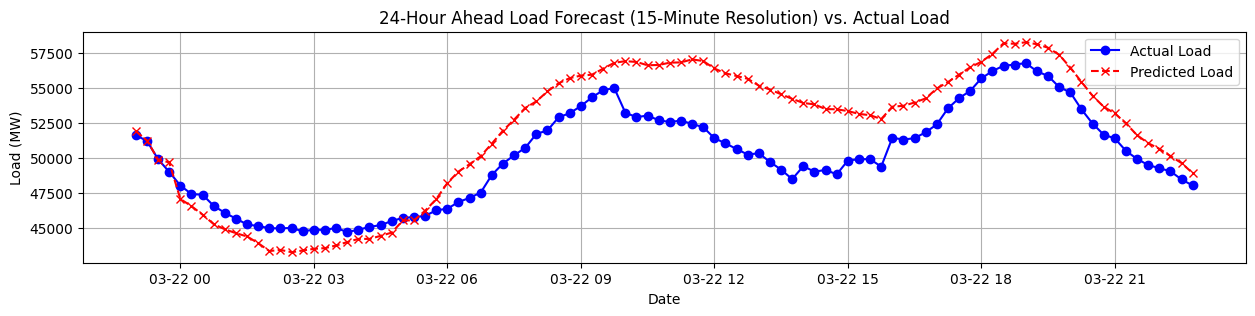

/tmp/ipython-input-1614849296.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_datetime = pd.date_range(start='2025-03-23 00:00:00', periods=96, freq='15T', tz='Europe/Berlin')


In [ ]:
plt.figure(figsize=(15, 3))
plt.plot(y_test.index, y_test.values, label='Actual Load', color='blue', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted Load', color='red', linestyle='--', marker='x')
plt.title('24-Hour Ahead Load Forecast (15-Minute Resolution) vs. Actual Load')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.show()

# To get the final forecast for the next 24 hours (March 23, 2025)
future_datetime = pd.date_range(start='2025-03-23 00:00:00', periods=96, freq='15T', tz='Europe/Berlin')
future_df = pd.DataFrame(index=future_datetime)

future_df['hour_of_day'] = future_df.index.hour
future_df['day_of_week'] = future_df.index.dayofweek
future_df['month'] = future_df.index.month
future_df['quarter_of_hour'] = future_df.index.minute // 15

# Get the last 96 points for lag_96
future_df['lag_96'] = load_data['load_mw'].iloc[-96:].values

# Get the load from 1 week prior (672 steps back)
future_df['lag_672'] = load_data['load_mw'].iloc[-672:-576].values

future_predictions = model.predict(future_df[features])

# print("\n--- Final Forecast for March 23, 2025 (15-Minute Intervals) ---")
# for dt, pred in zip(future_df.index, future_predictions):
#     print(f"{dt.strftime('%Y-%m-%d %H:%M')}: {pred:.2f} MW")